# Siren Classifier — Baseline Model (exp01)

Notebook eksplorasi end-to-end: **manifest → split → log-mel → CNN 2D → evaluasi**.

Target: baseline macro-F1 untuk 4 kelas (`ambulance`, `firetruck`, `police`, `traffic`) di dataset **D2**.

> Notebook ini sengaja monolitik untuk iterasi cepat. Setelah angka baseline stabil, isinya di-refactor ke `ml/src/`.

## Fakta dataset (hasil audit)

| | D1 | D2 |
|---|---|---|
| Kelas | ambulance, firetruck, traffic | ambulance, firetruck, police, traffic |
| Jumlah | 600 | 1675 |
| Sample rate | 44.1k / 48k / 22.05k (campur) | 44.1 kHz (seragam) |
| Channel | mayoritas stereo | stereo |
| Durasi | 3.0 s (semua) | 3.0 s (semua) |

**Dua temuan yang menentukan desain split:**

1. **Setiap sirine di D2 punya tepat 2 varian** — `mixed_sound_N.wav` dan `mixed_sound_N_1.wav`
   (ambulance 200 id, firetruck 200 id, police 227 id). Keduanya berasal dari rekaman sirine yang sama
   dengan overlay noise berbeda. Random split akan menaruh pasangan ini di train **dan** test →
   akurasi menggelembung. Karena itu split wajib `GroupShuffleSplit` by `source_id`.
2. **D1 ambulance punya 4 file duplikat** (200 file, 196 unik) — di-drop saat manifest by content hash.

Durasi sudah 3.0 s semua, jadi tidak perlu pad/crop — cukup **resample 22050 + mono + peak normalize**.

In [1]:
import hashlib
import json
import re
import warnings
from datetime import datetime
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             confusion_matrix, f1_score)
from sklearn.model_selection import GroupShuffleSplit
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")

print(f"tensorflow {tf.__version__} | librosa {librosa.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU') or 'none (CPU mode)'}")

tensorflow 2.16.2 | librosa 0.10.2.post1
GPU: none (CPU mode)


d:\Coding Vscode\Siren Classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---------------------------------------------------------------- config
EXP_ID = "exp01_baseline"
SEED = 42

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "Dataset"
ARTIFACTS = ROOT / "ml" / "artifacts" / EXP_ID
CACHE = ROOT / "ml" / "cache"
for d in (ARTIFACTS, CACHE):
    d.mkdir(parents=True, exist_ok=True)

# audio
SR = 22050
DURATION = 3.0
N_SAMPLES = int(SR * DURATION)

# log-mel
N_FFT = 1024
HOP = 512
N_MELS = 64
FMIN, FMAX = 20, SR // 2
N_FRAMES = N_SAMPLES // HOP + 1
INPUT_SHAPE = (N_MELS, N_FRAMES, 1)

# training
CLASSES = ["ambulance", "firetruck", "police", "traffic"]
N_CLASSES = len(CLASSES)
BATCH_SIZE = 32
EPOCHS = 60
LR = 1e-3
VAL_SIZE, TEST_SIZE = 0.15, 0.15

np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"input shape : {INPUT_SHAPE}")
print(f"artifacts   : {ARTIFACTS}")

input shape : (64, 130, 1)
artifacts   : d:\Coding Vscode\Siren Classification\ml\artifacts\exp01_baseline


## 1 · Manifest

Scan file → tabel dengan `path`, `label`, `source_id`, `dataset`.

`source_id` adalah kunci anti-leakage. Aturannya:

- `mixed_sound_57.wav` dan `mixed_sound_57_1.wav` → `source_id` **sama** (`d2_ambulance_57`)
- id diberi prefix kelas, karena penomoran diulang antar kelas (ambulance 1–200 *dan* firetruck 1–200 — tanpa prefix keduanya akan dianggap satu grup)
- traffic D2 (`sound_N.wav`) tidak berpasangan → 1 file = 1 grup

In [3]:
SOURCES = {
    "D1": {
        "ambulance": DATA / "Dataset1/sounds/ambulance",
        "firetruck": DATA / "Dataset1/sounds/firetruck",
        "traffic":   DATA / "Dataset1/sounds/traffic",
    },
    "D2": {
        "ambulance": DATA / "Dataset2/Dataset/Dataset/ambulance",
        "firetruck": DATA / "Dataset2/Dataset/Dataset/firetruck",
        "police":    DATA / "Dataset2/Dataset/Dataset/police",
        "traffic":   DATA / "Dataset2/traffic/traffic",
    },
}


def parse_source_id(stem: str, dataset: str, label: str) -> str:
    """Varian dari rekaman yang sama harus memetakan ke id yang sama."""
    m = re.search(r"(\d+)", stem)
    base = m.group(1) if m else stem
    return f"{dataset.lower()}_{label}_{base}"


def build_manifest(sources: dict) -> pd.DataFrame:
    rows = []
    for dataset, classes in sources.items():
        for label, folder in classes.items():
            if not folder.exists():
                raise FileNotFoundError(folder)
            for f in sorted(folder.glob("*.wav")):
                rows.append({
                    "path": str(f),
                    "filename": f.name,
                    "label": label,
                    "dataset": dataset,
                    "source_id": parse_source_id(f.stem, dataset, label),
                    "md5": hashlib.md5(f.read_bytes()).hexdigest(),
                })
    return pd.DataFrame(rows)


manifest = build_manifest(SOURCES)

# buang duplikat byte-identical (D1 ambulance punya 4)
before = len(manifest)
manifest = manifest.drop_duplicates(subset="md5", keep="first").reset_index(drop=True)
print(f"dropped {before - len(manifest)} duplikat → {len(manifest)} file")

manifest.to_csv(ROOT / "ml" / "manifest_full.csv", index=False)
manifest.groupby(["dataset", "label"]).agg(
    n_files=("path", "size"), n_sources=("source_id", "nunique")
)

dropped 4 duplikat → 2271 file


n_files  n_sources
dataset label                        
D1      ambulance      196        196
        firetruck      200        200
        traffic        200        200
D2      ambulance      400        200
        firetruck      400        200
        police         454        227
        traffic        421        421

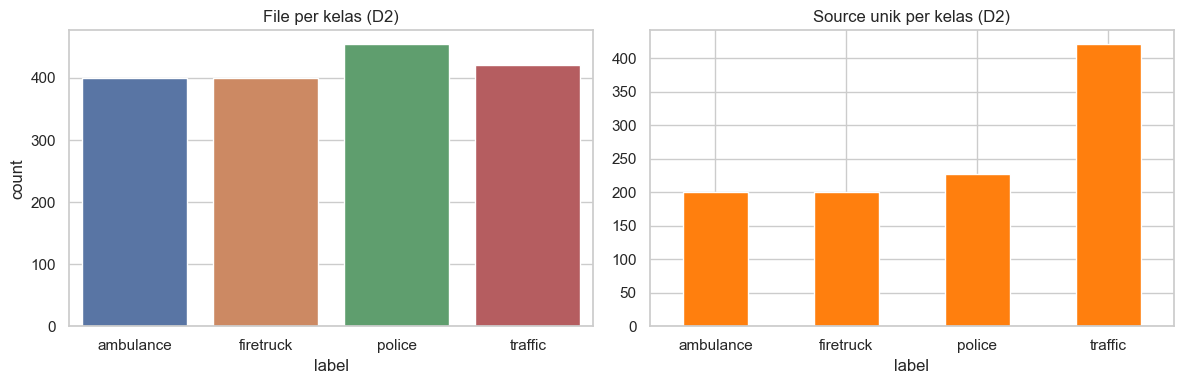

1675 file / 1048 source = 1.60 file per source
→ mayoritas sirine punya 2 varian. Random split = leakage.


In [4]:
# --- manifest produksi: D2 saja, 4 kelas ---
df = manifest[manifest.dataset == "D2"].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="label", order=CLASSES, ax=axes[0], hue="label", legend=False)
axes[0].set_title("File per kelas (D2)")
df.groupby("label")["source_id"].nunique().reindex(CLASSES).plot(
    kind="bar", ax=axes[1], color="tab:orange", rot=0
)
axes[1].set_title("Source unik per kelas (D2)")
plt.tight_layout()
plt.show()

ratio = len(df) / df.source_id.nunique()
print(f"{len(df)} file / {df.source_id.nunique()} source = {ratio:.2f} file per source")
print("→ mayoritas sirine punya 2 varian. Random split = leakage.")

## 2 · Split (group-aware)

70 / 15 / 15 dengan `GroupShuffleSplit` by `source_id`, dua tahap: pisahkan test dulu, lalu val dari sisanya.
Assert di bawah memastikan tidak ada `source_id` yang muncul di lebih dari satu split — kalau ini pernah gagal,
seluruh angka evaluasi tidak bisa dipercaya.

In [5]:
def group_split(frame, test_size, seed):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    a, b = next(gss.split(frame, groups=frame.source_id))
    return frame.iloc[a].reset_index(drop=True), frame.iloc[b].reset_index(drop=True)


trainval, test_df = group_split(df, TEST_SIZE, SEED)
train_df, val_df = group_split(trainval, VAL_SIZE / (1 - TEST_SIZE), SEED)

for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    part.to_csv(ROOT / "ml" / f"split_{name}.csv", index=False)

# --- verifikasi anti-leakage ---
s_tr, s_va, s_te = (set(p.source_id) for p in (train_df, val_df, test_df))
assert not (s_tr & s_va), f"leak train/val: {s_tr & s_va}"
assert not (s_tr & s_te), f"leak train/test: {s_tr & s_te}"
assert not (s_va & s_te), f"leak val/test: {s_va & s_te}"
print("✅ tidak ada source_id yang bocor antar split\n")

summary = pd.DataFrame({
    name: part.label.value_counts().reindex(CLASSES)
    for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]
}).fillna(0).astype(int)
summary.loc["TOTAL"] = summary.sum()
summary

✅ tidak ada source_id yang bocor antar split



,train,val,test
label,,,
ambulance,276,52,72
firetruck,272,66,62
police,330,60,64
traffic,293,69,59
TOTAL,1171,247,257


## 3 · Feature extraction — log-mel spectrogram

`load_audio` menyamakan sample rate ke 22050, mono, dan peak-normalize.
Hasil ekstraksi di-cache ke `.npy` supaya re-run notebook tidak mengulang decoding ~1.6k file.

In [6]:
def load_audio(path: str) -> np.ndarray:
    """→ mono, 22050 Hz, tepat 3.0 s, peak-normalized."""
    y, _ = librosa.load(path, sr=SR, mono=True, duration=DURATION)
    if len(y) < N_SAMPLES:                       # jaga-jaga file pendek
        y = np.pad(y, (0, N_SAMPLES - len(y)))
    y = y[:N_SAMPLES]
    peak = np.abs(y).max()
    return y / peak if peak > 0 else y


def logmel(y: np.ndarray) -> np.ndarray:
    mel = librosa.feature.melspectrogram(
        y=y, sr=SR, n_fft=N_FFT, hop_length=HOP,
        n_mels=N_MELS, fmin=FMIN, fmax=FMAX, power=2.0,
    )
    return librosa.power_to_db(mel, ref=np.max).astype(np.float32)


print("shape cek:", logmel(load_audio(df.path.iloc[0])).shape, "| target:", INPUT_SHAPE[:2])

shape cek: (64, 130) | target: (64, 130)


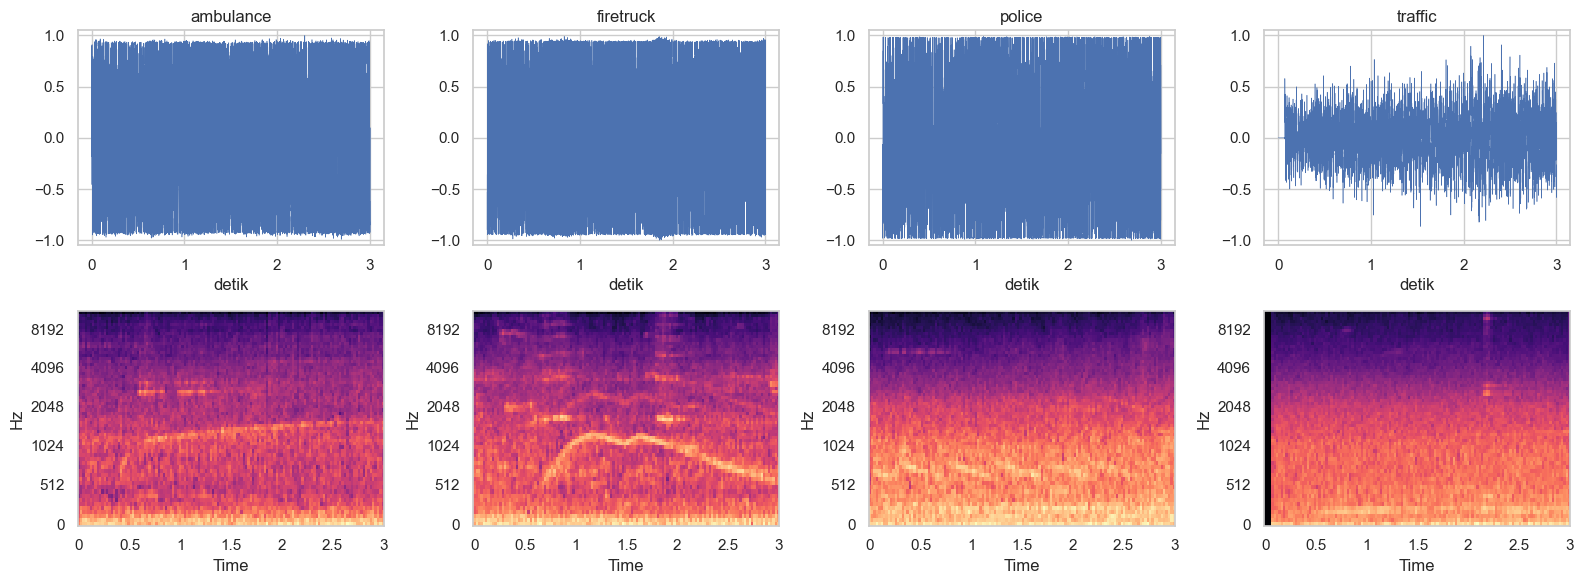

In [7]:
# --- lihat satu contoh per kelas ---
fig, axes = plt.subplots(2, N_CLASSES, figsize=(4 * N_CLASSES, 6))
for i, cls in enumerate(CLASSES):
    y = load_audio(df[df.label == cls].path.iloc[0])
    axes[0, i].plot(np.linspace(0, DURATION, len(y)), y, lw=0.4)
    axes[0, i].set(title=cls, xlabel="detik", ylim=(-1.05, 1.05))
    librosa.display.specshow(logmel(y), sr=SR, hop_length=HOP,
                             x_axis="time", y_axis="mel", ax=axes[1, i])
plt.tight_layout()
plt.show()

In [8]:
def extract_split(frame: pd.DataFrame, name: str):
    """Ekstrak (atau load dari cache) fitur untuk satu split."""
    fx = CACHE / f"{name}_X.npy"
    fy = CACHE / f"{name}_y.npy"
    if fx.exists() and fy.exists():
        X, y = np.load(fx), np.load(fy)
        if len(X) == len(frame):
            print(f"{name:5s} ← cache {X.shape}")
            return X, y
    X = np.stack([logmel(load_audio(p))
                  for p in tqdm(frame.path, desc=f"extract {name}")])
    y = frame.label.map({c: i for i, c in enumerate(CLASSES)}).to_numpy(np.int32)
    np.save(fx, X)
    np.save(fy, y)
    print(f"{name:5s} → {X.shape}")
    return X, y


X_train, y_train = extract_split(train_df, "train")
X_val,   y_val   = extract_split(val_df,   "val")
X_test,  y_test  = extract_split(test_df,  "test")

extract train: 100%|██████████| 1171/1171 [00:06<00:00, 181.62it/s]


train → (1171, 64, 130)


extract val: 100%|██████████| 247/247 [00:01<00:00, 175.03it/s]


val   → (247, 64, 130)


extract test: 100%|██████████| 257/257 [00:01<00:00, 174.18it/s]

test  → (257, 64, 130)


In [9]:
# Normalisasi: statistik HANYA dari train, lalu diterapkan ke val/test.
# Hitung dari val/test = leakage halus yang gampang kelewat.
MEAN, STD = float(X_train.mean()), float(X_train.std())
print(f"train mean={MEAN:.3f} std={STD:.3f}")


def to_dataset(X, y, training=False):
    X = ((X - MEAN) / STD)[..., np.newaxis]
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(len(X), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


ds_train = to_dataset(X_train, y_train, training=True)
ds_val   = to_dataset(X_val,   y_val)
ds_test  = to_dataset(X_test,  y_test)

print("batch:", next(iter(ds_train))[0].shape)

train mean=-30.361 std=12.945
batch: (32, 64, 130, 1)


## 4 · Model — CNN 2D VGG-style

4 blok konvolusi (32→64→128→128) dengan BatchNorm, ditutup `GlobalAveragePooling2D`.
GAP dipilih ketimbang `Flatten` agar jumlah parameter kecil — dataset hanya ~1.1k sampel train,
head `Flatten` + `Dense` akan overfit cepat.

In [10]:
def conv_block(x, filters, name):
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False,
                               name=f"{name}_conv")(x)
    x = tf.keras.layers.BatchNormalization(name=f"{name}_bn")(x)
    x = tf.keras.layers.Activation("relu", name=f"{name}_relu")(x)
    return tf.keras.layers.MaxPooling2D(2, name=f"{name}_pool")(x)


def build_model(input_shape, n_classes, lr):
    inp = tf.keras.Input(shape=input_shape, name="logmel")
    x = inp
    for i, f in enumerate([32, 64, 128, 128], start=1):
        x = conv_block(x, f, f"block{i}")
    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
    x = tf.keras.layers.Dropout(0.3, name="drop")(x)
    out = tf.keras.layers.Dense(n_classes, activation="softmax", name="pred")(x)

    model = tf.keras.Model(inp, out, name="siren_cnn2d")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model = build_model(INPUT_SHAPE, N_CLASSES, LR)
model.summary()

Model: "siren_cnn2d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ logmel (InputLayer)             │ (None, 64, 130, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv (Conv2D)            │ (None, 64, 130, 32)    │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn (BatchNormalization)  │ (None, 64, 130, 32)    │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu (Activation)        │ (None, 64, 130, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv (Conv2D)            │ (None, 32, 65, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn (BatchNormalization)  │ (None, 32, 65, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu (Activation)        │ (None, 32, 65, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv (Conv2D)            │ (None, 16, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn (BatchNormalization)  │ (None, 16, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu (Activation)        │ (None, 16, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 16, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv (Conv2D)            │ (None, 8, 16, 128)     │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_bn (BatchNormalization)  │ (None, 8, 16, 128)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_relu (Activation)        │ (None, 8, 16, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop (Dropout)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,828 (944.64 KB)

 Trainable params: 241,124 (941.89 KB)

 Non-trainable params: 704 (2.75 KB)

## 5 · Training

`EarlyStopping` memantau `val_loss` dan mengembalikan bobot terbaik, jadi `EPOCHS=60` adalah batas atas, bukan target.

In [11]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=12,
                                     restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                         patience=5, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(str(ARTIFACTS / "best.keras"),
                                       monitor="val_loss", save_best_only=True),
]

history = model.fit(ds_train, validation_data=ds_val,
                    epochs=EPOCHS, callbacks=callbacks, verbose=1)

Epoch 1/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 159ms/step - accuracy: 0.5474 - loss: 1.0550 - val_accuracy: 0.5344 - val_loss: 1.2339 - learning_rate: 0.0010
Epoch 2/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 157ms/step - accuracy: 0.7208 - loss: 0.6956 - val_accuracy: 0.2105 - val_loss: 1.5140 - learning_rate: 0.0010
Epoch 3/60
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.7700 - loss: 0.5899

KeyboardInterrupt: 

In [ ]:
h = history.history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, key in zip(axes, ["loss", "accuracy"]):
    ax.plot(h[key], label="train")
    ax.plot(h[f"val_{key}"], label="val")
    ax.set(title=key, xlabel="epoch")
    ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACTS / "training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

## 6 · Evaluasi

Metrik utama **macro-F1** (bukan accuracy) — kelas sedikit tidak seimbang dan tiap kelas sama pentingnya.

In [ ]:
def evaluate(model, ds, y_true, split_name):
    proba = model.predict(ds, verbose=0)
    y_pred = proba.argmax(1)
    macro = f1_score(y_true, y_pred, average="macro")
    acc = (y_pred == y_true).mean()
    print(f"\n=== {split_name} — acc {acc:.4f} | macro-F1 {macro:.4f} ===")
    print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3))
    return {"acc": float(acc), "f1_macro": float(macro)}, y_pred


val_metrics, _ = evaluate(model, ds_val, y_val, "VAL")
test_metrics, y_pred_test = evaluate(model, ds_test, y_test, "TEST")

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(
    ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=45)
axes[0].set_title("Test — jumlah")
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_test, normalize="true"),
    display_labels=CLASSES,
).plot(ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f",
       xticks_rotation=45)
axes[1].set_title("Test — recall per kelas")
plt.tight_layout()
plt.savefig(ARTIFACTS / "confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

## 7 · Simpan artifact + log eksperimen

Sesuai keputusan di PLANNING.md (skip MLflow): satu baris per eksperimen di `ml/experiments.csv`,
plus folder artifact berisi model, config, dan metrics.

In [ ]:
config = {
    "exp_id": EXP_ID, "seed": SEED,
    "sr": SR, "duration": DURATION,
    "n_fft": N_FFT, "hop": HOP, "n_mels": N_MELS, "fmin": FMIN, "fmax": FMAX,
    "classes": CLASSES, "batch_size": BATCH_SIZE, "epochs_max": EPOCHS, "lr": LR,
    "norm_mean": MEAN, "norm_std": STD,
    "model": "cnn2d_vgg_gap", "augment": "none",
    "n_train": len(train_df), "n_val": len(val_df), "n_test": len(test_df),
}
metrics = {"val": val_metrics, "test": test_metrics,
           "epochs_ran": len(h["loss"])}

model.save(ARTIFACTS / "model.keras")
(ARTIFACTS / "config.json").write_text(json.dumps(config, indent=2))
(ARTIFACTS / "metrics.json").write_text(json.dumps(metrics, indent=2))

row = {
    "exp_id": EXP_ID,
    "date": datetime.now().strftime("%Y-%m-%d"),
    "config_file": f"ml/artifacts/{EXP_ID}/config.json",
    "feature": f"logmel_{N_MELS}",
    "model": "cnn2d_vgg_gap",
    "augment": "none",
    "val_acc": round(val_metrics["acc"], 4),
    "val_f1_macro": round(val_metrics["f1_macro"], 4),
    "test_acc": round(test_metrics["acc"], 4),
    "test_f1_macro": round(test_metrics["f1_macro"], 4),
    "notes": "baseline D2 4-class, group split by source_id",
}

exp_csv = ROOT / "ml" / "experiments.csv"
log = pd.read_csv(exp_csv) if exp_csv.exists() else pd.DataFrame()
log = log[log.exp_id != EXP_ID] if "exp_id" in log.columns else log
log = pd.concat([log, pd.DataFrame([row])], ignore_index=True)
log.to_csv(exp_csv, index=False)

print(f"artifacts → {ARTIFACTS}")
log

---

## Langkah berikutnya

1. Catat macro-F1 test sebagai **angka baseline** — semua eksperimen berikutnya dibandingkan ke sini.
2. Periksa confusion matrix: kalau `ambulance` ↔ `firetruck` banyak tertukar, itu wajar (pola sirine mirip) dan jadi bahan analisis laporan.
3. Fase 3a — SpecAugment (exp02), noise mixing (exp03), kombinasi (exp04).
4. Setelah baseline stabil, refactor notebook ini ke `ml/src/` (`features/logmel.py`, `data/dataset.py`, `models/cnn2d.py`, `training/train.py`) dengan config YAML.